# Outline of an approach for combining mutltiple sequential analyses

This short demo show how you could build a "joint" model using the sequential interface for bagelR. The idea is that you create two distinct models and run them together. At each iteration the weigts for each can be obtained and transformed as required. These transformed weights can then be assigned to the models prior to analysing the next data point. 

This demonstration is contrived as it 

- models change in mean and change in slope (probably not a practical consideration - especially when working offline).
- the weights are not transformed (this is left for you to determine and implmenet the appropriate transformation

Once you have tested your ideas using sequential bagel, you could then wrap your code into a function that takes the parameters for each model along with the data, and then runs the models across all of the data in a loop until termination or when the thresnold is exceeded.


## Check version

In [1]:
packageVersion("bagelR")

[1] ‘1.5.0’

## Load library

In [2]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




### Define feature vector, prior and transform functions for model 1 (change in mean in this demo)

In [3]:
feature_vector_1 <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

In [4]:
prior_1  <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

In [5]:
transform_1  <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

### Define feature vector, prior and transform functions for model 2 (change in slope in this demo) 

In [6]:
feature_vector_2 <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

In [7]:
prior_2 <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

In [8]:
transform_2 <- function(tau)
{
	return(matrix(c(1,tau+1,1,tau+1,0,1,0,1),2,4,byrow=TRUE))
}

#### Define parameters for model 1

In [9]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

#### Create model 1

In [10]:
bagel_object_1 <- sequential_bagel_kv_approximate(feature_vector_1,prior_1,transform_1,p0,p,noise_sd,max_particles)

#### Define parameters for model 2

In [11]:
p <- 1.0;
p0 <- 0.8;
noise_sd <- 1.6;
max_particles <- 200


#### Create model 2

In [12]:
bagel_object_2 <- sequential_bagel_kv_approximate(feature_vector_2,prior_2,transform_2,p0,p,noise_sd,max_particles)

#### Generate some data - change at t = 501 

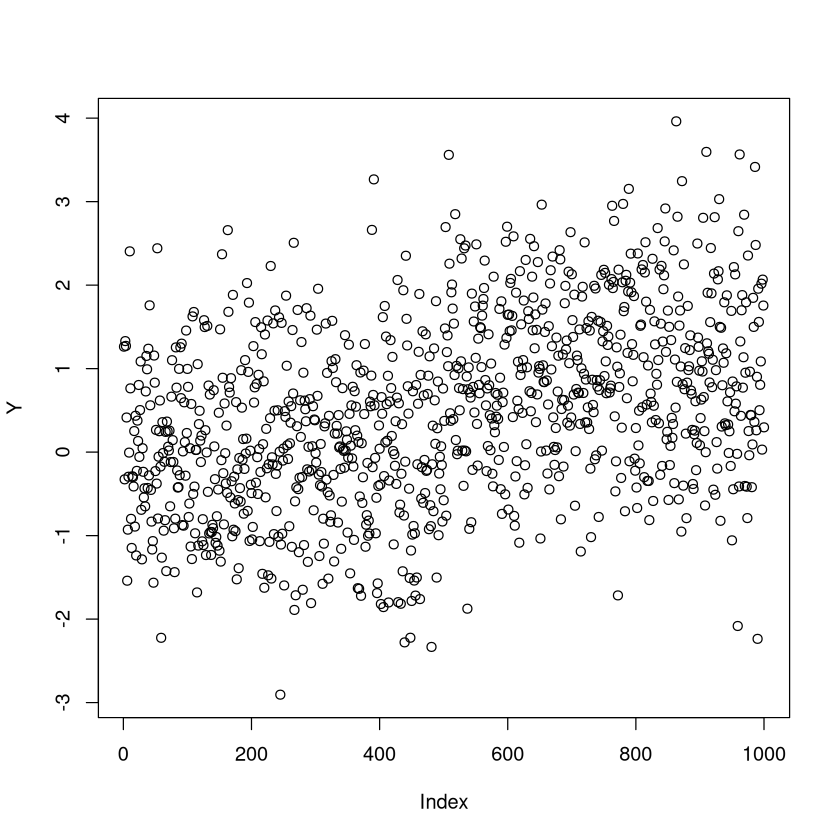

In [13]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Set threshold

In [14]:
threshold <- 0.8

#### Analyse the data

In [15]:
w0ts_1 <- list()
w0ts_2 <- list()
for(y in Y)
{
   w0t <- update(bagel_object_1,y)
   w0ts_1 <- append(w0ts_1,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
   w0t <- update(bagel_object_2,y)
   w0ts_2 <- append(w0ts_2,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
    ### THIS IS WHERE YOU CAN EXTRACT, MODIFY, and CHANGE THE WEIGHTS IN THE MODELS
    # extract weights
    weights_1 <- weights(bagel_object_1)
    weights_2 <- weights(bagel_object_2)
    # transform weights
    #### YOUR CODE GOES HERE !!!!
    # weights_1 <- .....
    # weights_2 <- .....
    ####
    # reset weights
    set_weights(bagel_object_1,weights_1)
    set_weights(bagel_object_2,weights_2)
}

In [16]:
w0ts_1

[[1]]
[1] 0.9

[[2]]
[1] 0.8988952

[[3]]
[1] 0.9153046

[[4]]
[1] 0.9191612

[[5]]
[1] 0.9245338

[[6]]
[1] 0.8835316

[[7]]
[1] 0.8452336

[[8]]
[1] 0.8524461

[[9]]
[1] 0.8706424

[[10]]
[1] 0.9023028

[[11]]
[1] 0.9121749

[[12]]
[1] 0.9194789

[[13]]
[1] 0.9039756

[[14]]
[1] 0.9041514

[[15]]
[1] 0.9037651

[[16]]
[1] 0.9009094

[[17]]
[1] 0.9108915

[[18]]
[1] 0.899174

[[19]]
[1] 0.9120132

[[20]]
[1] 0.8942305

[[21]]
[1] 0.896994

[[22]]
[1] 0.9089878

[[23]]
[1] 0.9146104

[[24]]
[1] 0.9235106

[[25]]
[1] 0.9258463

[[26]]
[1] 0.9299418

[[27]]
[1] 0.9320467

[[28]]
[1] 0.9341491

[[29]]
[1] 0.9275392

[[30]]
[1] 0.930949

[[31]]
[1] 0.9313996

[[32]]
[1] 0.9292306

[[33]]
[1] 0.9278833

[[34]]
[1] 0.9241853

[[35]]
[1] 0.9326379

[[36]]
[1] 0.9374061

[[37]]
[1] 0.9378758

[[38]]
[1] 0.9412128

[[39]]
[1] 0.9401727

[[40]]
[1] 0.9435139

[[41]]
[1] 0.9357781

[[42]]
[1] 0.9356048

[[43]]
[1] 0.9430732

[[44]]
[1] 0.9463748

[[45]]
[1] 0.9441762

[[46]]
[1] 0.9380939

[[47]]
[1] 0.9147437

[[48]]
[1] 0.9410584

[[49]]
[1] 0.9465341

[[50]]
[1] 0.9475893

[[51]]
[1] 0.9492948

[[52]]
[1] 0.9493125

[[53]]
[1] 0.9448771

[[54]]
[1] 0.9515411

[[55]]
[1] 0.9526932

[[56]]
[1] 0.9534551

[[57]]
[1] 0.9535626

[[58]]
[1] 0.9546159

[[59]]
[1] 0.9475489

[[60]]
[1] 0.9368091

[[61]]
[1] 0.9470992

[[62]]
[1] 0.9493677

[[63]]
[1] 0.9446482

[[64]]
[1] 0.9462848

[[65]]
[1] 0.941754

[[66]]
[1] 0.9462537

[[67]]
[1] 0.9350805

[[68]]
[1] 0.9423725

[[69]]
[1] 0.9461716

[[70]]
[1] 0.9480489

[[71]]
[1] 0.9493918

[[72]]
[1] 0.9513817

[[73]]
[1] 0.9497778

[[74]]
[1] 0.9503305

[[75]]
[1] 0.9533054

[[76]]
[1] 0.9549814

[[77]]
[1] 0.955976

[[78]]
[1] 0.9567109

[[79]]
[1] 0.9558312

[[80]]
[1] 0.9506802

[[81]]
[1] 0.9474796

[[82]]
[1] 0.9547269

[[83]]
[1] 0.956559

[[84]]
[1] 0.9571964

[[85]]
[1] 0.9570573

[[86]]
[1] 0.9566458

[[87]]
[1] 0.9586069

[[88]]
[1] 0.9588862

[[89]]
[1] 0.9592271

[[90]]
[1] 0.9590075

[[91]]
[1] 0.9550386

[[92]]
[1] 0.959888

[[93]]
[1] 0.9606709

[[94]]
[1] 0.9612475

[[95]]
[1] 0.9618223

[[96]]
[1] 0.9622018

[[97]]
[1] 0.9626178

[[98]]
[1] 0.9611683

[[99]]
[1] 0.9615347

[[100]]
[1] 0.9591693

[[101]]
[1] 0.9568237

[[102]]
[1] 0.9612539

[[103]]
[1] 0.9628491

[[104]]
[1] 0.9633657

[[105]]
[1] 0.9635069

[[106]]
[1] 0.9643261

[[107]]
[1] 0.9634467

[[108]]
[1] 0.9642636

[[109]]
[1] 0.9651299

[[110]]
[1] 0.9628583

[[111]]
[1] 0.9647222

[[112]]
[1] 0.9655355

[[113]]
[1] 0.965941

[[114]]
[1] 0.9662363

[[115]]
[1] 0.9640831

[[116]]
[1] 0.966305

[[117]]
[1] 0.9653054

[[118]]
[1] 0.9663176

[[119]]
[1] 0.9669233

[[120]]
[1] 0.9672093

[[121]]
[1] 0.9674024

[[122]]
[1] 0.9676428

[[123]]
[1] 0.9669467

[[124]]
[1] 0.9658099

[[125]]
[1] 0.9628498

[[126]]
[1] 0.9669101

[[127]]
[1] 0.9659203

[[128]]
[1] 0.9668057

[[129]]
[1] 0.9678624

[[130]]
[1] 0.9682479

[[131]]
[1] 0.9676805

[[132]]
[1] 0.9686693

[[133]]
[1] 0.9682759

[[134]]
[1] 0.9690306

[[135]]
[1] 0.9691068

[[136]]
[1] 0.9692691

[[137]]
[1] 0.9678092

[[138]]
[1] 0.9658182

[[139]]
[1] 0.9633809

[[140]]
[1] 0.9597929

[[141]]
[1] 0.9654569

[[142]]
[1] 0.9664884

[[143]]
[1] 0.9663168

[[144]]
[1] 0.963275

[[145]]
[1] 0.9591564

[[146]]
[1] 0.9557462

[[147]]
[1] 0.9474582

[[148]]
[1] 0.9463775

[[149]]
[1] 0.954514

[[150]]
[1] 0.9459411

[[151]]
[1] 0.9593816

[[152]]
[1] 0.953203

[[153]]
[1] 0.9546212

[[154]]
[1] 0.9628247

[[155]]
[1] 0.9634663

[[156]]
[1] 0.9656231

[[157]]
[1] 0.9656214

[[158]]
[1] 0.9668577

[[159]]
[1] 0.9673146

[[160]]
[1] 0.9673023

[[161]]
[1] 0.967984

[[162]]
[1] 0.967752

[[163]]
[1] 0.9653389

[[164]]
[1] 0.9532174

[[165]]
[1] 0.950128

[[166]]
[1] 0.9467066

[[167]]
[1] 0.9605906

[[168]]
[1] 0.9557495

[[169]]
[1] 0.9620419

[[170]]
[1] 0.967388

[[171]]
[1] 0.9598956

[[172]]
[1] 0.9664224

[[173]]
[1] 0.9680381

[[174]]
[1] 0.9694994

[[175]]
[1] 0.970083

[[176]]
[1] 0.9705306

[[177]]
[1] 0.9700407

[[178]]
[1] 0.9704271

[[179]]
[1] 0.9700485

[[180]]
[1] 0.

#### Check results

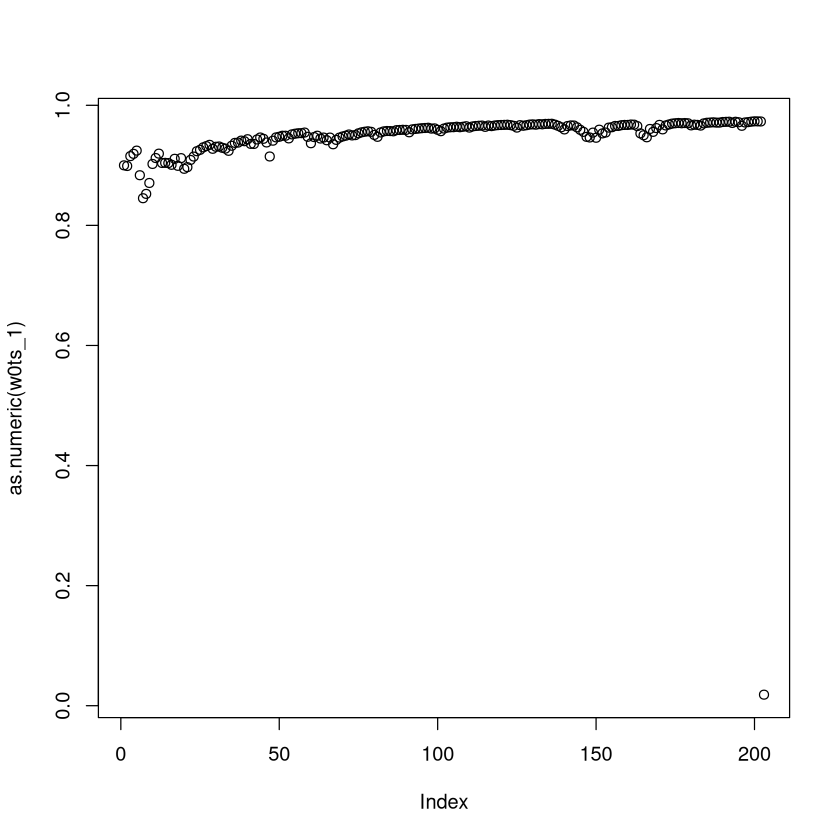

In [17]:
plot(as.numeric(w0ts_1))

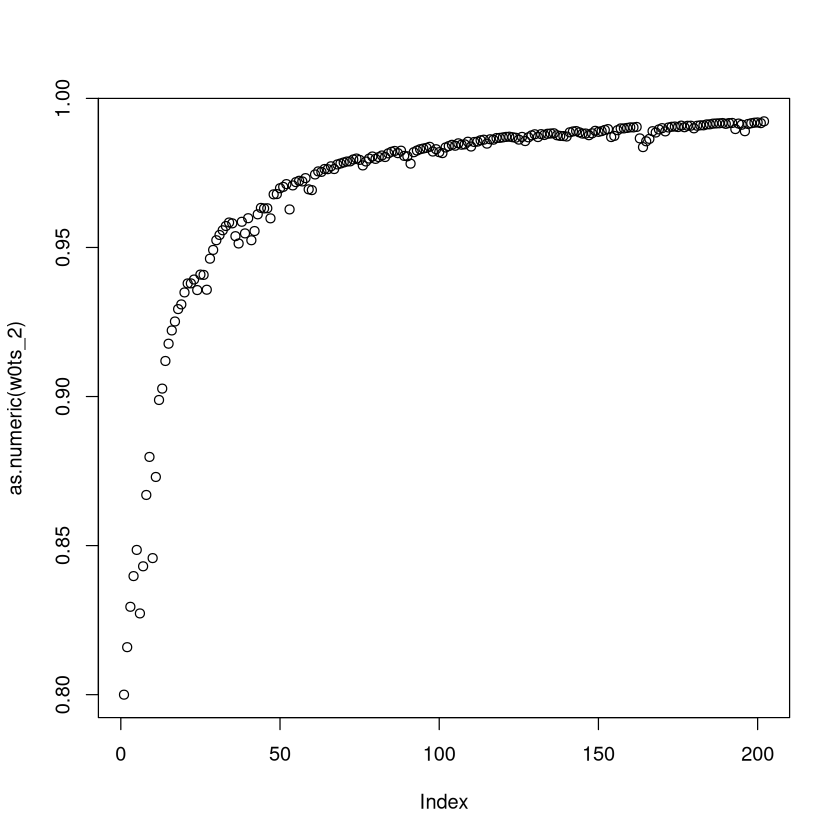

In [18]:
plot(as.numeric(w0ts_2))